# 1. Install library

# 2. Importing library and defining plotting functions

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mmcfilters
import pandas as pd
import math

from IPython import display
np.set_printoptions(suppress=True, threshold=np.inf, linewidth=np.inf, precision=2)  # Ajuste o linewidth conforme necessário

from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back

def printSimpleTree():
    printTree = PrettyPrintTree(
        lambda node: node.children,
        lambda node: f"ID:{node.id}\nLevel: {node.level}\n|cnps|: {len(node.cnps)}\nArea: {node.area}",
        color=Back.BLACK + Fore.WHITE,
    )
    return printTree

def printTreeWithAttribute(attrType, attrValue):
    printTree = PrettyPrintTree(
        lambda node: node.children,
        lambda node: f"ID: {node.id}\nLevel: {node.level}\n|cnps|: {len(node.cnps)}\nArea: {node.area}\n{attrType.name}: {attrValue[node.id]}",
        color=Back.BLACK + Fore.WHITE
    )
    return printTree


def showLevelSets(img_f):
    print("Upper and lower level sets where in black are foreground pixels and white are background pixels")
    t_values = np.unique(img_f)
    len = np.size(t_values)
    max_value = np.max(img_f)
    fig, axes = plt.subplots(len, 2, figsize=(5, 15))

    # Preenchendo os subplots com imagens limiares
    for i, t in enumerate(t_values):
        # Primeira coluna: img_f >= t
        thr = t_values[i]
        img_threshold_ge = np.where(img_f >= thr, 1, 0)
        axes[i, 0].imshow(img_threshold_ge, cmap='gray_r', vmax=1, vmin=0, interpolation='nearest')
        axes[i, 0].set_title(f'image ≥ {t}')
        axes[i, 0].axis('off')
        axes[i, 0].add_patch(plt.Rectangle((0, 0), img_threshold_ge.shape[1] - 1, img_threshold_ge.shape[0] - 1,
                                   edgecolor='red', linewidth=0.5, fill=False))
        # Segunda coluna: img_f <= t
        thr = t_values[len - i -1]
        img_threshold_le = np.where(img_f <= thr, 1, 0)
        axes[i, 1].imshow(img_threshold_le, cmap='gray_r',vmax=1, vmin=0, interpolation='nearest')
        axes[i, 1].set_title(f'image ≤ {thr}')
        axes[i, 1].axis('off')
        axes[i, 1].add_patch(plt.Rectangle((0, 0), img_threshold_le.shape[1] - 1, img_threshold_le.shape[0] - 1,
                                   edgecolor='blue', linewidth=0.5, fill=False))

    # Ajuste de layout para evitar sobreposição
    plt.tight_layout()
    plt.show()


def computeCentroid(cnps):
    closest_pixel = cnps[len(cnps)//2]
    px, py = closest_pixel // num_cols, closest_pixel % num_cols
    return px, py

def showTree(tree, printTree=printSimpleTree()):
    if(tree.treeType == 0):
        print("Imagem and its max-tree representation. The indexes of max-tree nodes are shown as label in the imagem.")
    elif(tree.treeType == 1):
        print("Imagem and its min-tree representation. The indexes of min-tree nodes are shown as label in the imagem.")
    else:
        print("Imagem and its tree of shapes representation. The indexes of tree of shapes nodes are shown as label in the imagem.")
    img_vector = tree.reconstructionImage()
    ids_position = []

    for node in tree.root.postOrderTraversal():
      px, py = computeCentroid(node.cnps)
      ids_position.append( (node.id, px, py) )

    # Plota a imagem
    plt.figure(figsize=(8, 6))
    image = img_vector.reshape(tree.numRows, tree.numCols)
    # Adicionando uma borda ao redor da imagem
    ax = plt.gca()  # Obtém o eixo atual
    ax.add_patch(plt.Rectangle((0, 0), image.shape[1] - 1, image.shape[0] - 1,
                               edgecolor='red', linewidth=0.5, fill=False))

    plt.imshow(image, cmap='gray')

    # Adiciona rótulos nos centróides fictícios
    for i, (id, x, y) in enumerate(ids_position):
        plt.text(y, x, f'•{id}', color='red', fontsize=9)


    plt.axis('off')
    plt.show()
    printTree(tree.root)

def showNode(node):
    image = node.recNode().reshape(num_rows, num_cols)
    ax = plt.gca()  # Obtém o eixo atual
    ax.imshow(image, cmap='gray_r')
    ax.add_patch(plt.Rectangle((0, 0), image.shape[1] - 1, image.shape[0] - 1,
                               edgecolor='red', linewidth=0.5, fill=False))
    ax.set_title(f"{node}")
    ax.axis("off")

def buildMapIds(tree):
    mapIds = np.zeros(num_rows*num_cols)
    for p in range(num_rows*num_cols):
        mapIds[p] = tree.getSC(p).id
    return mapIds




# 3. Creating the morphological tree of an input image

Upper and lower level sets where in black are foreground pixels and white are background pixelsCreating tree by union-find for integer image.



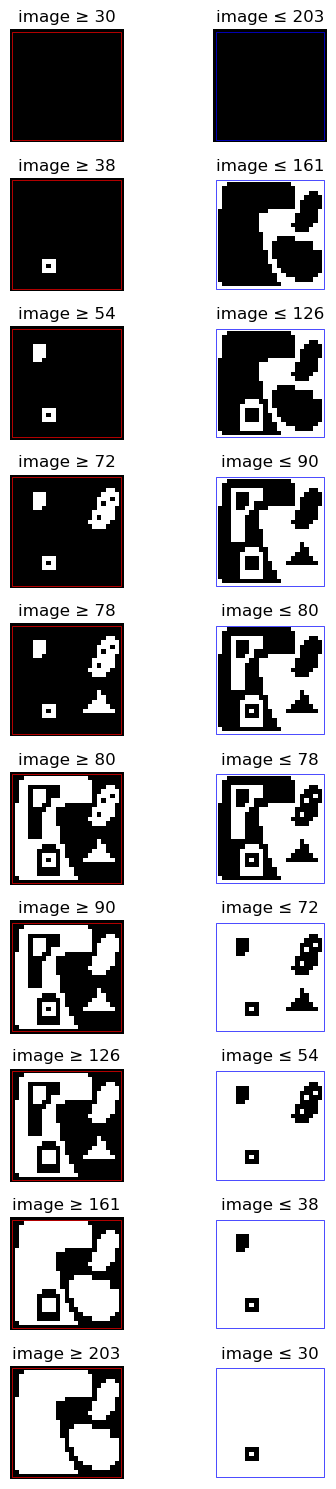




Imagem and its min-tree representation. The indexes of min-tree nodes are shown as label in the imagem.


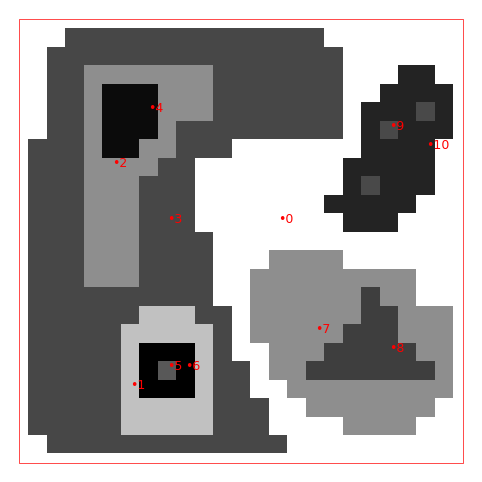

                                  ID:0        
                                  Level: 203  
                                  |cnps|: 226 
                                  Area: 625   
                      ┌────────────────┴────┬────────────┐
                  ID:1                  ID:7         ID:9       
                  Level: 161            Level: 126   Level: 80  
                  |cnps|: 24            |cnps|: 66   |cnps|: 3  
                  Area: 277             Area: 84     Area: 38   
            ┌─────────┴─────────┐           |            |      
        ID:2                ID:5        ID:8         ID:10      
        Level: 126          Level: 90   Level: 72    Level: 54  
        |cnps|: 42          |cnps|: 1   |cnps|: 18   |cnps|: 35 
        Area: 244           Area: 9     Area: 18     Area: 35   
      ┌─────┴──────┐            |                               
 ID:3          ID:4         ID:6                                
 Level: 78     Level: 38    Level: 30 

In [3]:
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

imgInput = np.array([
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203,203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203],
        [203,203, 78, 78,126,126,126,126,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203,203, 54, 54,203,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203, 54, 54, 54, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203, 54, 54, 54, 80, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126, 78, 78, 78, 78, 78, 78, 78, 78, 78,203, 54, 80, 54, 54, 54,203],
        [203, 78, 78, 78,126, 38, 38,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126,126, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203,203, 54, 80, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,126,126,126,126,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,126,126,126,126,126,126, 72,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78,161,161,161, 78, 78,203,126,126,126,126,126,126, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78,203,126,126,126,126,126, 72, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78,203,203,126,126,126, 72, 72, 72, 72, 72,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 90, 30,161, 78, 78,203,126,126, 72, 72, 72, 72, 72, 72, 72,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,126,126,126,126,126,126,126,203,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,203,203,126,126,126,126,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203],
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203]
], dtype=np.uint8)
(num_rows, num_cols) = imgInput.shape

isMaxtree = False
tree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, isMaxtree)
Type = mmcfilters.Attribute.Type


showLevelSets(imgInput)
print("\n\n")
showTree(tree)

# 4. Available attributes

In [17]:
describe = {}
for atributo, valor in Type.__dict__.items():
    if(str(valor).startswith("Type.")):
        describe[str(valor).split('.')[1]] = mmcfilters.Attribute.describe(valor)

df = pd.DataFrame(describe.items(), columns=['Attribute type', 'Description'])
df.style.set_caption("<H3><b>Available attributes</b></H3>")

,Attribute type,Description
0,AREA,Area: Number of pixels in the connected component.
1,VOLUME,"Volume: Sum of the gray-level intensities of all pixels in the connected component. Interpreted as the total mass under the component, or the integral of the image function over its support."
2,RELATIVE_VOLUME,Relative volume: Sum of differences between the node level and the gray-levels of pixels in the component. Measures the amount of intensity required to fill the component to its node level.
3,LEVEL,Level: Gray-level at which the connected component appears in the threshold decomposition hierarchy; corresponds to the altitude of the node in the component tree.
4,GRAY_HEIGHT,"GRAY_HEIGHT: For a node in the max-tree, the difference between its level and the maximum level among its descendants; analogously, in the min-tree, the difference to the minimum level among its descendants."
5,MEAN_LEVEL,Mean level: Average gray-level intensity of the pixels in the connected component.
6,VARIANCE_LEVEL,Variance of level: Variance of the gray-level values of the pixels in the connected component.
7,BOX_WIDTH,Bounding box width: Width of the minimum rectangle enclosing the connected component.
8,BOX_HEIGHT,Bounding box height: Height of the minimum rectangle enclosing the connected component.
9,RECTANGULARITY,Rectangularity: Ratio between the connected component area and the area of its bounding box. Values closer to 1 indicate shapes that efficiently fill their bounding box.


# 5. Computing a single attribute

In [20]:
Type = mmcfilters.Attribute.Type

attrType = Type.BITQUADS_AREA
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, attrType)

print(f"{attrType.name} (numpy): {attrValue}")

BITQUADS_AREA (numpy): [625.   278.38 246.12 194.    11.12   9.     8.5   85.12  18.75  39.12  37.62]


Imagem and its min-tree representation. The indexes of min-tree nodes are shown as label in the imagem.


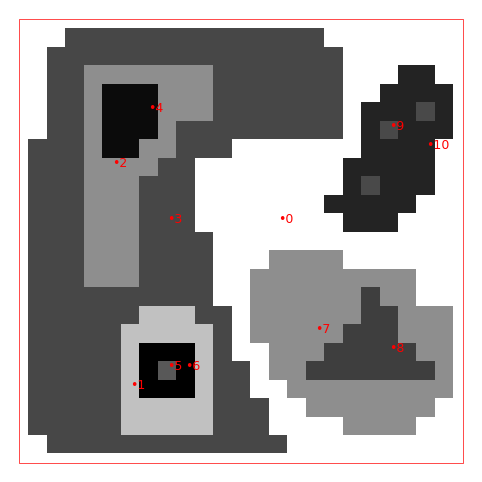

                                                              ID: 0                
                                                              Level: 203           
                                                              |cnps|: 226          
                                                              Area: 625            
                                                              BITQUADS_AREA: 625.0 
                                       ┌───────────────────────────────┴───────┬───────────────────────┐
                             ID: 1                                   ID: 7                   ID: 9                 
                             Level: 161                              Level: 126              Level: 80             
                             |cnps|: 24                              |cnps|: 66              |cnps|: 3             
                             Area: 277                               Area: 84                Area: 38              
           

In [22]:
showTree(tree, printTreeWithAttribute(attrType, attrValue))

# 6. Computing multiple attribute

In [25]:
Type = mmcfilters.Attribute.Type

dic, attrs = mmcfilters.Attribute.computeAttributes(tree, [Type.AREA, Type.GRAY_HEIGHT, Type.VOLUME, Type.RELATIVE_VOLUME])
#print(attrs[:, dic['GRAY_HEIGHT']])
pd.DataFrame(attrs, columns=dic, index=pd.Index(range(len(attrs)), name="NodeID"))


,AREA,VOLUME,RELATIVE_VOLUME,GRAY_HEIGHT
NodeID,,,,
0,625.0,82422.0,45993.0,174.0
1,277.0,24802.0,20535.0,132.0
2,244.0,20608.0,10582.0,89.0
3,191.0,14898.0,191.0,0.0
4,11.0,418.0,11.0,0.0
5,9.0,330.0,497.0,61.0
6,8.0,240.0,8.0,0.0
7,84.0,9612.0,1074.0,55.0
8,18.0,1296.0,18.0,0.0


# Filtering

Text(0.5, 1.0, 'attribute filter')

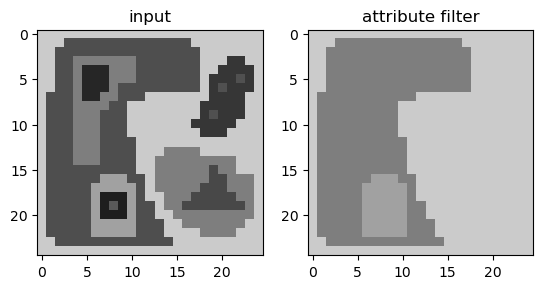

In [28]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
threshold = 80

attFilter = mmcfilters.AttributeFilters(tree)
imgFiltered = attFilter.filteringSubtractiveRule(attrValue > threshold)

plt.subplot(1,2, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(imgFiltered.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

# Extraction of extinction values

Regional extrema (folha): NodeCT(id=6, level=30, numCNPs=8, area=8
Valor do extincao:  61.0
Local (persistencia) que a regional extrema ainda existir: NodeCT(id=5, level=90, numCNPs=1, area=9
A regional extrema não existem em: NodeCT(id=1, level=161, numCNPs=24, area=277

Regional extrema (folha): NodeCT(id=8, level=72, numCNPs=18, area=18
Valor do extincao:  55.0
Local (persistencia) que a regional extrema ainda existir: NodeCT(id=7, level=126, numCNPs=66, area=84
A regional extrema não existem em: NodeCT(id=0, level=203, numCNPs=226, area=625

Regional extrema (folha): NodeCT(id=10, level=54, numCNPs=35, area=35
Valor do extincao:  27.0
Local (persistencia) que a regional extrema ainda existir: NodeCT(id=9, level=80, numCNPs=3, area=38
A regional extrema não existem em: NodeCT(id=0, level=203, numCNPs=226, area=625

Regional extrema (folha): NodeCT(id=3, level=78, numCNPs=191, area=191
Valor do extincao:  0.0
Local (persistencia) que a regional extrema ainda existir: NodeCT(id=0, lev

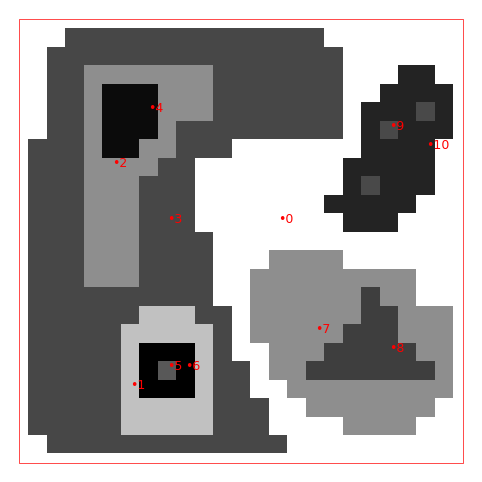

                                  ID:0        
                                  Level: 203  
                                  |cnps|: 226 
                                  Area: 625   
                      ┌────────────────┴────┬────────────┐
                  ID:1                  ID:7         ID:9       
                  Level: 161            Level: 126   Level: 80  
                  |cnps|: 24            |cnps|: 66   |cnps|: 3  
                  Area: 277             Area: 84     Area: 38   
            ┌─────────┴─────────┐           |            |      
        ID:2                ID:5        ID:8         ID:10      
        Level: 126          Level: 90   Level: 72    Level: 54  
        |cnps|: 42          |cnps|: 1   |cnps|: 18   |cnps|: 35 
        Area: 244           Area: 9     Area: 18     Area: 35   
      ┌─────┴──────┐            |                               
 ID:3          ID:4         ID:6                                
 Level: 78     Level: 38    Level: 30 

In [31]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
extinctionValues = mmcfilters.ExtinctionValues(tree, attrValue) #o atributo precisa ser crescente 

for extrema in extinctionValues.getExtinctionValues():
    print("Regional extrema (folha):", extrema.leaf)
    print("Valor do extincao: ", extrema.extinction)
    print("Local (persistencia) que a regional extrema ainda existir:", extrema.cutoffNode)
    print("A regional extrema não existem em:", extrema.cutoffNode.parent)
    print()

showTree(tree)

# Filtering by extinction values

Text(0.5, 1.0, 'keeping 3 regional extremes')

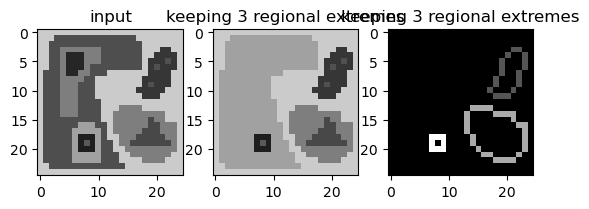

In [34]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
extinctionValues = mmcfilters.ExtinctionValues(tree, attrValue)

keepExtrema = 3 #mantem numLeafToKeep folhas com maiores valores de extinção
saliency = extinctionValues.saliencyMap(keepExtrema)
filtering = extinctionValues.filtering(keepExtrema)

plt.subplot(1,3, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(filtering.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('keeping 3 regional extremes')

plt.subplot(1,3, 3)
plt.imshow(saliency.reshape(num_rows, num_cols), cmap='gray')
plt.title('keeping 3 regional extremes')

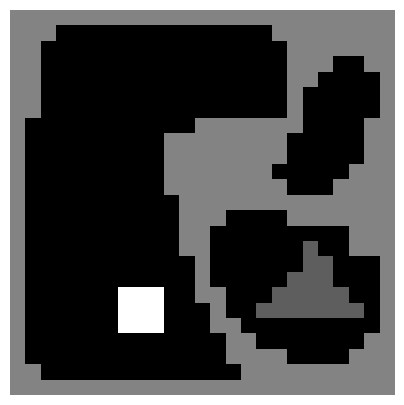

In [36]:
attrMap = mmcfilters.Attribute.computerAttributeMapping(tree, Type.ECCENTRICITY)

attrMap = attrMap

attrMap2 = np.maximum(0.1, 1 - np.abs(1 - attrMap))


plt.figure(figsize=(5, 5))
plt.imshow(attrMap2.reshape(num_rows, num_cols), cmap='gray')
plt.axis('off')
plt.show()

In [38]:
# Opção para imprimir tudo, sem abreviações
np.set_printoptions(threshold=np.inf, linewidth=np.inf, precision=2)  # Ajuste o linewidth conforme necessário

#print(attrMap2.reshape(num_rows, num_cols))

#para restaurar o padrão:
#np.set_printoptions(threshold=1000)
attrMap2.reshape(num_rows, num_cols)

array([[0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57],
       [0.57, 0.57, 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57],
       [0.57, 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.57, 0.57, 0.57, 0.57, 0.57, 0.57, 0.57],
       [0.57, 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.57, 0.57, 0.57, 0.1 , 0.1 , 0.57, 0.57],
       [0.57, 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.57, 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.57],
       [0.57, 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.57],
       [0.57, 0.57, 0.1 , 0.1 , 0.1 , 0.1 , 0.

Creating tree by union-find for floating point image.


Text(0.5, 1.0, 'attribute filter')

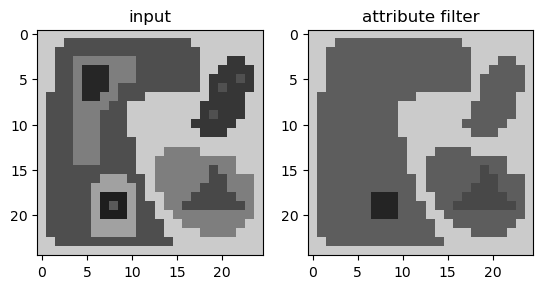

In [40]:
tree2 = mmcfilters.MorphologicalTree.createFromAttributeMapping(attrMap2, imgInput, num_rows, num_cols, True, 1.5)
imgRec = tree2.reconstructionImage()

plt.subplot(1,2, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')


In [42]:

attrValue = mmcfilters.Attribute.computeSingleAttribute(tree2, Type.GRAY_HEIGHT)
extinctionValues = mmcfilters.ExtinctionValues(tree2, attrValue)

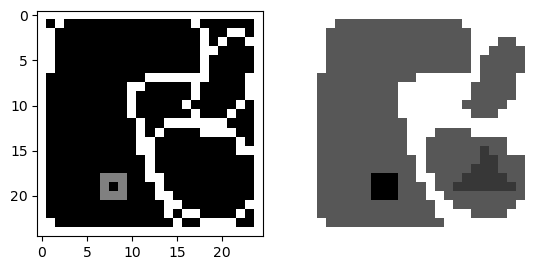

In [44]:
keepExtrema = 3
saliency = extinctionValues.saliencyMap(keepExtrema)
filtering = extinctionValues.filtering(keepExtrema)

plt.subplot(1,2, 1)
plt.imshow(saliency.reshape(num_rows, num_cols), cmap='gray')
plt.subplot(1,2, 2)
plt.imshow(filtering.reshape(num_rows, num_cols), cmap='gray')
plt.axis('off')
plt.show()

# Brincando com a imagem da moeda

Creating tree by union-find for integer image.


Text(0.5, 1.0, 'attribute filter')

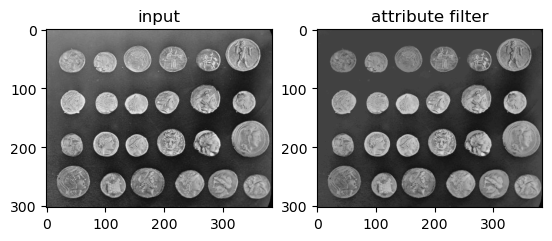

In [47]:
from skimage import data, img_as_float
imgInput = data.coins()
(num_rows, num_cols) = imgInput.shape

isMaxtree = True
tree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, isMaxtree)

attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
threshold = 10

circularity = mmcfilters.Attribute.computeSingleAttribute(tree, Type.CIRCULARITY)

attFilter = mmcfilters.AttributeFilters(tree)
imgFiltered = attFilter.filteringSubtractiveRule((attrValue > threshold) & (circularity > 0.13))

plt.subplot(1,2, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,2, 2)
plt.imshow(imgFiltered.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

Creating tree by union-find for integer image.


Text(0.5, 1.0, 'keeping 24 regional extremes')

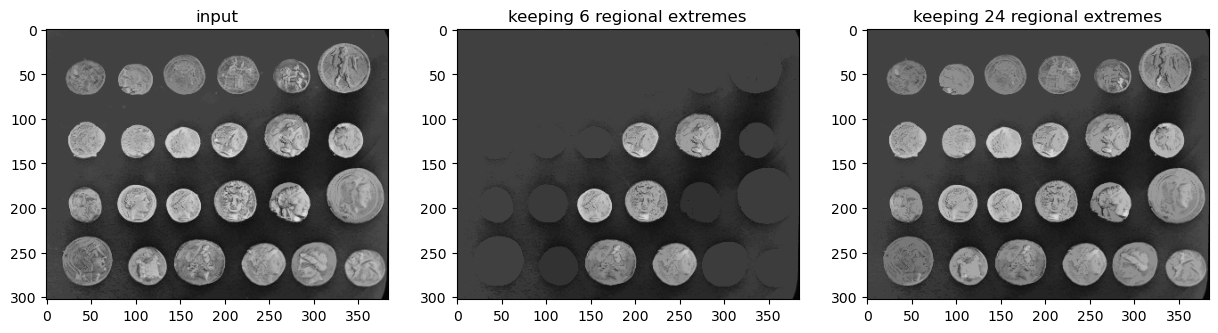

In [76]:
imgInput = imgFiltered.reshape(num_rows, num_cols)

isMaxtree = True
tree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, isMaxtree)
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.GRAY_HEIGHT)
extinctionValues = mmcfilters.ExtinctionValues(tree, attrValue)

numLeafToKeep = 6 #mantem numLeafToKeep folhas com maiores valores de extinção
imgFiltered6 = extinctionValues.filtering(numLeafToKeep)

numLeafToKeep = 24 #mantem numLeafToKeep folhas com maiores valores de extinção
imgFiltered24 = extinctionValues.filtering(numLeafToKeep)

plt.figure(figsize=(15, 5))
plt.subplot(1,3, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(imgFiltered6.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('keeping 6 regional extremes')

plt.subplot(1,3,3)
plt.imshow(imgFiltered24.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('keeping 24 regional extremes')

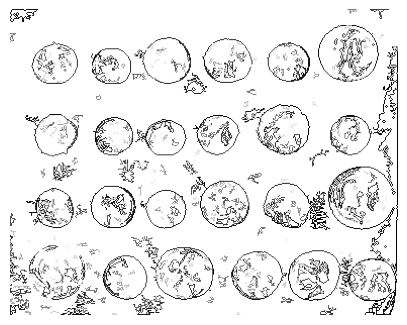

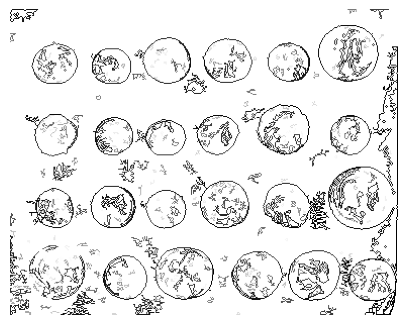

In [80]:
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, Type.AREA)

circularity = mmcfilters.Attribute.computerAttributeMapping(tree, Type.CIRCULARITY)

extinctionValues = mmcfilters.ExtinctionValues(tree, attrValue)
numLeafToKeep = int(len(tree.leaves) * 0.7) #5% das extremas regionais

countors = mmcfilters.Attribute.extractContoursNonCompact(tree)

contour_img = np.zeros((num_rows*num_cols), dtype=np.float32)
importance = numLeafToKeep
for extrema in sorted(extinctionValues.getExtinctionValues(), key=lambda extrema: extrema.extinction, reverse=True)[:numLeafToKeep]:
    for p in countors[extrema.cutoffNode.id]:
        contour_img[p]=importance
    importance -= 1


plt.figure(figsize=(5, 5))
plt.imshow(contour_img.reshape(num_rows, num_cols), cmap='Grays')
plt.axis('off')
plt.show()


saliencyMap = extinctionValues.saliencyMap(numLeafToKeep)
plt.figure(figsize=(5, 5))
plt.imshow(saliencyMap.reshape(num_rows, num_cols), cmap='Grays')
plt.axis('off')
plt.show()


Creating tree by union-find for integer image.
Creating tree by union-find for floating point image.


Text(0.5, 1.0, 'keeping 24 regional extremes')

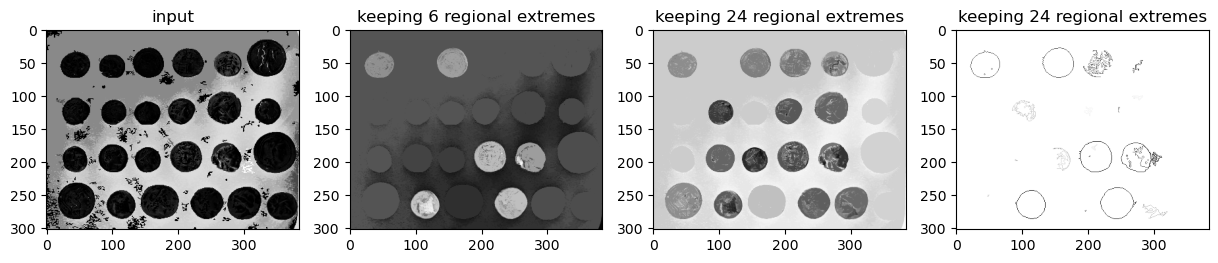

In [106]:
imgInput = imgFiltered.reshape(num_rows, num_cols)

isMaxtree = True
tree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, isMaxtree)

attrMap = mmcfilters.Attribute.computerAttributeMapping(tree, Type.VARIANCE_LEVEL)
#attrMap = np.maximum(0.1, 1 - np.abs(1 - attrMap))

tree2 = mmcfilters.MorphologicalTree.createFromAttributeMapping(attrMap, imgInput, num_rows, num_cols, False, 1)

attrValue = mmcfilters.Attribute.computeSingleAttribute(tree2, Type.GRAY_HEIGHT)
extinctionValues = mmcfilters.ExtinctionValues(tree2, attrValue)

numLeafToKeep = 6 #mantem numLeafToKeep folhas com maiores valores de extinção
imgFiltered6 = extinctionValues.filtering(numLeafToKeep)

numLeafToKeep = 24 #mantem numLeafToKeep folhas com maiores valores de extinção
imgFiltered24 = extinctionValues.filtering(numLeafToKeep)

plt.figure(figsize=(15, 5))
plt.subplot(1,4, 1)
plt.imshow(attrMap.reshape(num_rows, num_cols), cmap='gray')
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFiltered6.reshape(num_rows, num_cols), cmap='gray')
plt.title('keeping 6 regional extremes')

plt.subplot(1,4,3)
plt.imshow(imgFiltered24.reshape(num_rows, num_cols), cmap='Grays')
plt.title('keeping 24 regional extremes')

plt.subplot(1,4,4)
plt.imshow(extinctionValues.saliencyMap(numLeafToKeep).reshape(num_rows, num_cols), cmap='Grays')
plt.title('keeping 24 regional extremes')